In [110]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes


Fetch Data

In [111]:
diabetes = load_diabetes()
x = diabetes.data
y = diabetes.target

data = pd.DataFrame(x, columns=diabetes.feature_names)

data["Disease Progression"] = y
data.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Disease Progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [112]:
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [113]:
print(data.shape)

(442, 11)


In [114]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  442 non-null    float64
 1   sex                  442 non-null    float64
 2   bmi                  442 non-null    float64
 3   bp                   442 non-null    float64
 4   s1                   442 non-null    float64
 5   s2                   442 non-null    float64
 6   s3                   442 non-null    float64
 7   s4                   442 non-null    float64
 8   s5                   442 non-null    float64
 9   s6                   442 non-null    float64
 10  Disease Progression  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [115]:
data.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Disease Progression
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


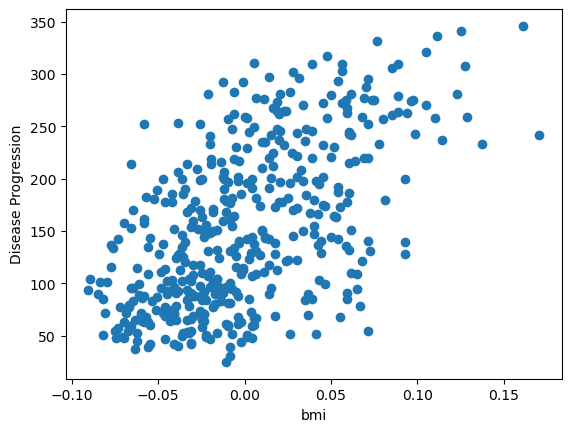

In [116]:
fig, ax = plt.subplots()
ax.scatter(x = data['bmi'], y = data['Disease Progression'])
plt.ylabel('Disease Progression')
plt.xlabel('bmi')
plt.show()

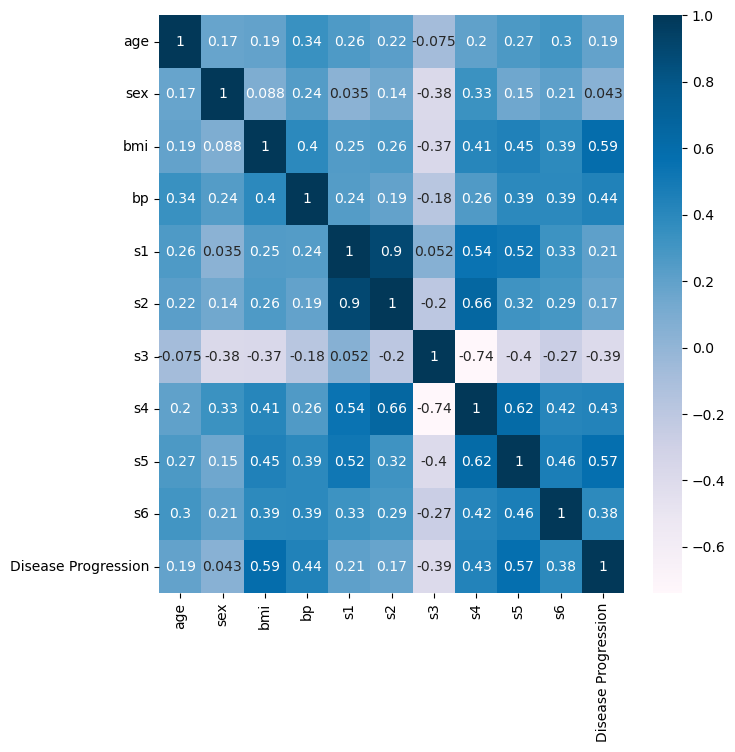

In [117]:
import seaborn as sns
fig = plt.figure(figsize = (7.5,7.5))
cor = data.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.PuBu)
plt.show()

In [118]:
cor_target = abs(cor["Disease Progression"])

relevant_features = []
names = []
for name, value in cor_target.items():
    if name != "Disease Progression" and value > 0.3:
        relevant_features.append(value)
        names.append(name)

print(names)
print(relevant_features)

['bmi', 'bp', 's3', 's4', 's5', 's6']
[0.5864501344746885, 0.44148175856257105, 0.39478925067091836, 0.43045288474477283, 0.5658825924427434, 0.3824834842485807]


Model Building

In [119]:
from sklearn.model_selection import train_test_split

x = data.drop("Disease Progression", axis=1)
y = data["Disease Progression"]

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [120]:
weights = np.zeros(x.shape[1])
bias = 3

#gradient descent
n = len(x_train)
learning_rate = 0.01
for i in range(2000):
    model = np.dot(x_train, weights) + bias
    
    cost = np.mean((model - y_train) ** 2)

    dw = (2/n) * np.dot(x_train.T, (model - y_train))
    db = (2/n) * np.sum(model - y_train)

    weights = weights - (learning_rate * dw)

    bias = bias - (learning_rate * db)

    if i % 100 == 0:  # print every 100 iterations
        print(f"iteration {i}, cost: {cost}")

print(weights)
print(bias)



iteration 0, cost: 28797.903682719545
iteration 100, cost: 6393.339664731755
iteration 200, cost: 5924.442598943156
iteration 300, cost: 5843.654651429948
iteration 400, cost: 5771.940699656735
iteration 500, cost: 5702.558384606193
iteration 600, cost: 5635.315510714546
iteration 700, cost: 5570.137650778997
iteration 800, cost: 5506.954929052589
iteration 900, cost: 5445.69994268815
iteration 1000, cost: 5386.30764085815
iteration 1100, cost: 5328.715241284845
iteration 1200, cost: 5272.862150303568
iteration 1300, cost: 5218.689885761662
iteration 1400, cost: 5166.142002642655
iteration 1500, cost: 5115.164021319075
iteration 1600, cost: 5065.703358340897
iteration 1700, cost: 5017.709259669915
iteration 1800, cost: 4971.132736273506
iteration 1900, cost: 4925.926501994309
[ 23.40128727  -2.22296007  79.32941847  59.10965684  21.92749616
  15.5524685  -48.5853449   52.40271984  71.46315543  49.65556875]
153.28205852946425


In [121]:

model = np.dot(x_test, weights) + bias
mse = np.mean((model - y_test) ** 2)
rmse = np.sqrt(mse)
r2 = 1 - (np.sum((y_test - model)**2) / np.sum((y_test - model.mean())**2))

print("Actual disease progression: ", y_test[0])
print("Model prediction", model[0])
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.2f}")

Actual disease progression:  151.0
Model prediction 160.61700498825164
MSE:  4256.44
RMSE: 65.24
R²:   0.20


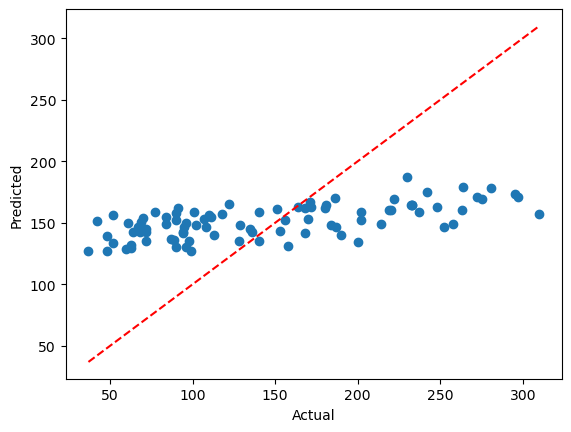

In [128]:
fig, ag = plt.subplots()
ag.scatter(y_test, model)
ag.set_ylabel('Predicted')
ag.set_xlabel('Actual')
ag.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') 
plt.show()

In [123]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [124]:
predictions = lr.predict(x_test)

print("Actual disease progression: ", y_test[0])
print("Model prediction", predictions[0])

Actual disease progression:  151.0
Model prediction 139.54755840379602


In [125]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
print(mse)
print(rmse)


2900.193628493482
53.85344583676593


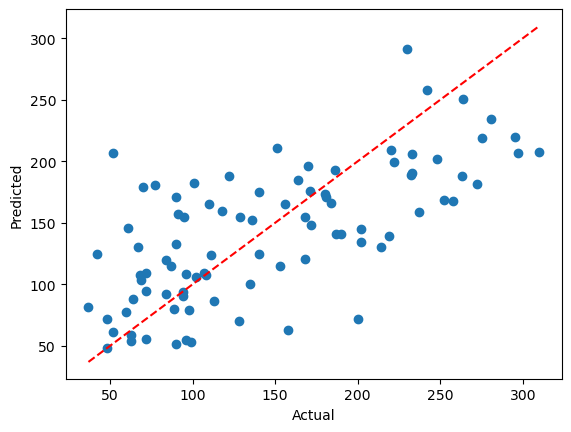

In [ ]:
fig, ay = plt.subplots()

ay.scatter(y_test, predictions)
ay.set_ylabel('Predicted')
ay.set_xlabel('Actual')
ay.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') 
plt.show()

In [ ]:

y_min = y.min()
y_max = y.max()

patients = {
    "Unhealthy": np.array([[0.085299, 0.050680, 0.061696, 0.059744, -0.005697, 0.079165, -0.028674, 0.034309, 0.031193, 0.044485]]),
    "Healthy":   np.array([[-0.089063, -0.044642, -0.051474, -0.081413, 0.083740, 0.027809, 0.173816, -0.039493, -0.068332, -0.092204]])
}

for name, patient in patients.items():
    prediction = np.dot(patient, weights) + bias
    percent = ((prediction[0] - y_min) / (y_max - y_min)) * 100
    percent = np.clip(percent, 0, 100)
    print(f"{name}: {percent:.1f}% disease progression")

Unhealthy: 45.9% disease progression
Healthy: 31.1% disease progression
